<div style="display: flex; background-color: RGB(0, 35, 160);" >
<h1 style="margin: auto; padding: 30px; color:#fff;">DETECTEZ DES FAUX BILLETS</h1>
</div>

<h1 style="color:RGB(31,119,180)">
ONCFM 
</h1>

<p>
<span style="color:RGB(31,119,180)">L'ONCFM (Organisation Nationale de lutte Contre le Faux-Monnayage) </span> est une organisation publique ayant pour objectif de mettre en place des méthodes d’identification des contrefaçons des billets en euros. 
<br />
Ce notebook permet de choisir un modèle de Machine Learning permettant de détecter des faux billets
</p>

<div style="background-color: RGB(31,119,180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">1.1 - Importation des librairies</h3>
</div>

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from scipy import stats
from scipy.stats import shapiro

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

from threadpoolctl import threadpool_limits
import joblib


<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">1.2 - Chargement des données</h3>
</div>

In [130]:
df_billets = pd.read_csv("data/in/billets.csv", sep=";")

<div style="background-color: RGB(31,119,180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire EDA</h2>
</div>


In [131]:
#Dimension du dataset
print("Le dataframe customer comporte {} lignes".format(df_billets.shape[0]))
print("Le dataframe customer comporte {} colonnes".format(df_billets.shape[1]))
print("-"*50)

#Liste des colonnes du dataset
print("Liste des colonnes du dataframe customers {}".format(list(df_billets.columns)))
print("-"*50)
#La nature des données dans chacune des colonnes
print("Nature des colonnes du dataframe customer \n{}".format(df_billets.dtypes))
print("-"*50)
#Le nombre de valeurs présentes dans chacune des colonnes
for column in list(df_billets.columns):
    print("Nombre de valeurs présentes dans la colonne {} : {}".format(column, len(df_billets.value_counts(column).reset_index())))



Le dataframe customer comporte 1500 lignes
Le dataframe customer comporte 7 colonnes
--------------------------------------------------
Liste des colonnes du dataframe customers ['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
--------------------------------------------------
Nature des colonnes du dataframe customer 
is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object
--------------------------------------------------
Nombre de valeurs présentes dans la colonne is_genuine : 2
Nombre de valeurs présentes dans la colonne diagonal : 159
Nombre de valeurs présentes dans la colonne height_left : 155
Nombre de valeurs présentes dans la colonne height_right : 170
Nombre de valeurs présentes dans la colonne margin_low : 285
Nombre de valeurs présentes dans la colonne margin_up : 123
Nombre de valeurs présentes dans la 

In [132]:
#Valeur manquantes par colonne
print("Nombre de valeurs manquantes par colonne")
missing_data_per_column = df_billets.isnull().sum()
print(missing_data_per_column)

Nombre de valeurs manquantes par colonne
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


In [133]:
#Recherche de lignes dupliquées
df_billets.loc[df_billets.duplicated(keep=False),:]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length


In [134]:
#Caractéristiques des colonnes
df_billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [135]:
#Nombre de vrai de de faux billets
df_billets["is_genuine"].value_counts()

is_genuine
True     1000
False     500
Name: count, dtype: int64

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    La colonne margin_low contient des données vides
    <br />
    Il n'y a pas de ligne dupliquée
    <br />
    Le fichier contient 500 faux billets et 1000 vrais billets
</p>
</div>

In [136]:
#Map contenant les caractéristiques des billets
map_caracteristiques_billets={
    "diagonal":"Diagonale du billet",
    "height_left":"Hauteur gauche du billet",
    "height_right":"Hauteur droite du billet",
    "margin_low":"Marge entre le bord inférieur et l'image du billet",
    "margin_up":"Marge entre le bord supérieur et l'image du billet",
    "length":"Longueur du billet",
    "is_genuine":"Type de billet"
}

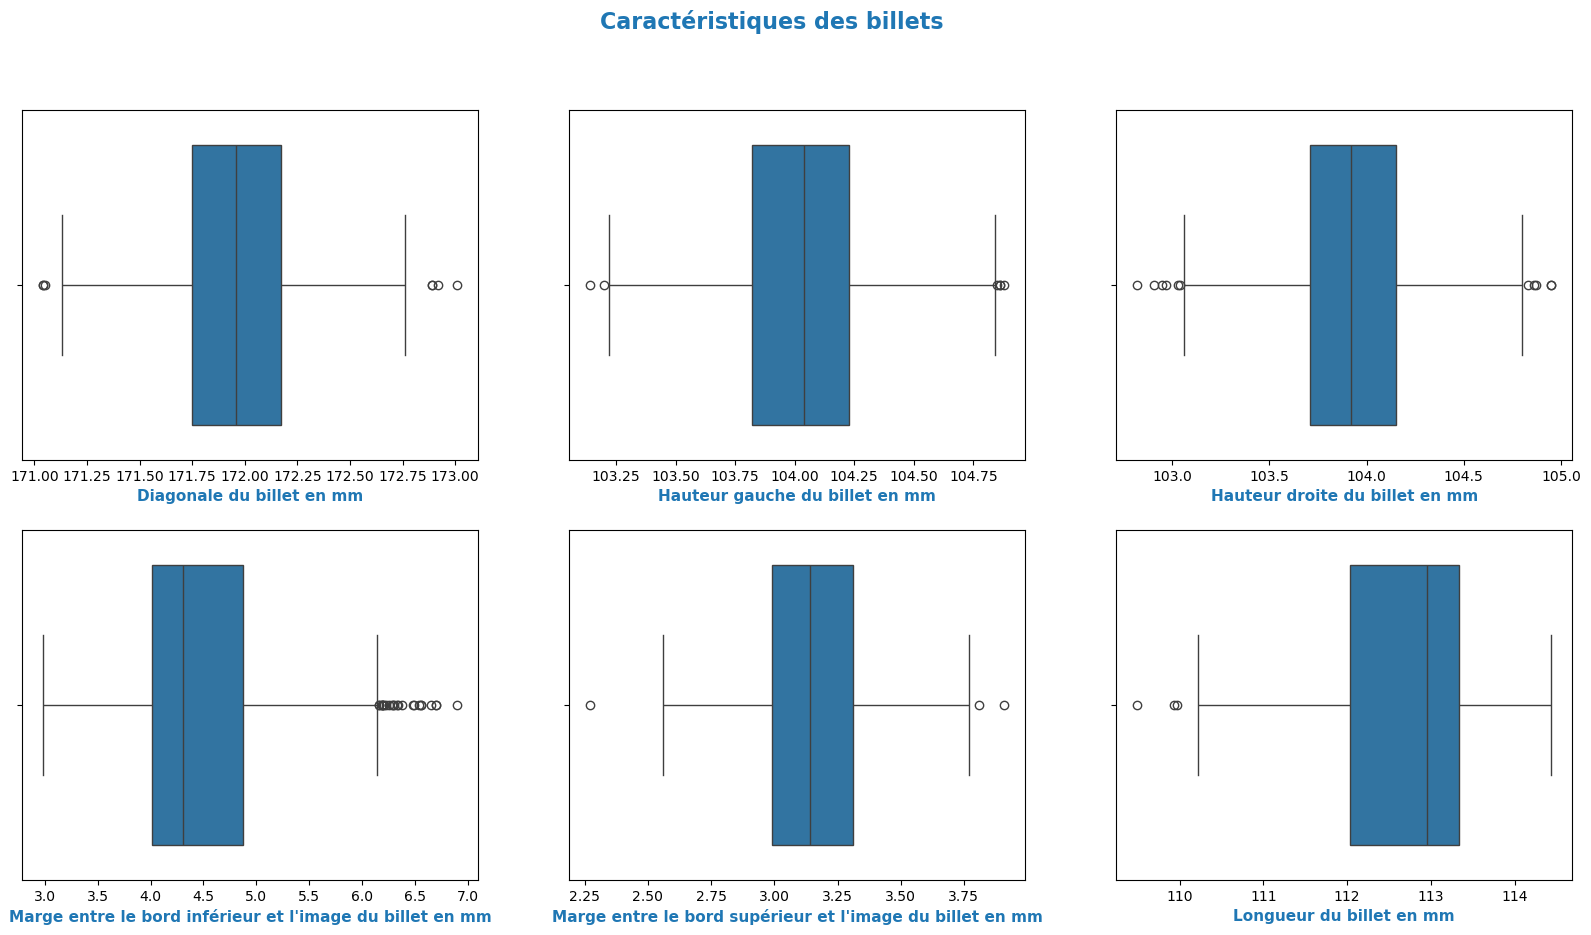

In [137]:
#boxplot des différentes variables
fig, axes = plt.subplots(2,3)
fig.set_size_inches(20, 10)

caracteristic_billets_nom = df_billets.columns.drop("is_genuine")
j= 0
for i, column in enumerate(caracteristic_billets_nom):
    sns.boxplot(data=df_billets, x=column, ax=axes[i // 3, j])
    axes[i // 3, j].set_xlabel(map_caracteristiques_billets[column] + ' en mm', fontsize=11, color="#1F77B4", weight="bold")

    if (j == 0) | (j == 1):
        j = j + 1
    else:
        j = 0
fig.suptitle("Caractéristiques des billets", fontsize=16, color="#1F77B4", weight="bold")
plt.show()


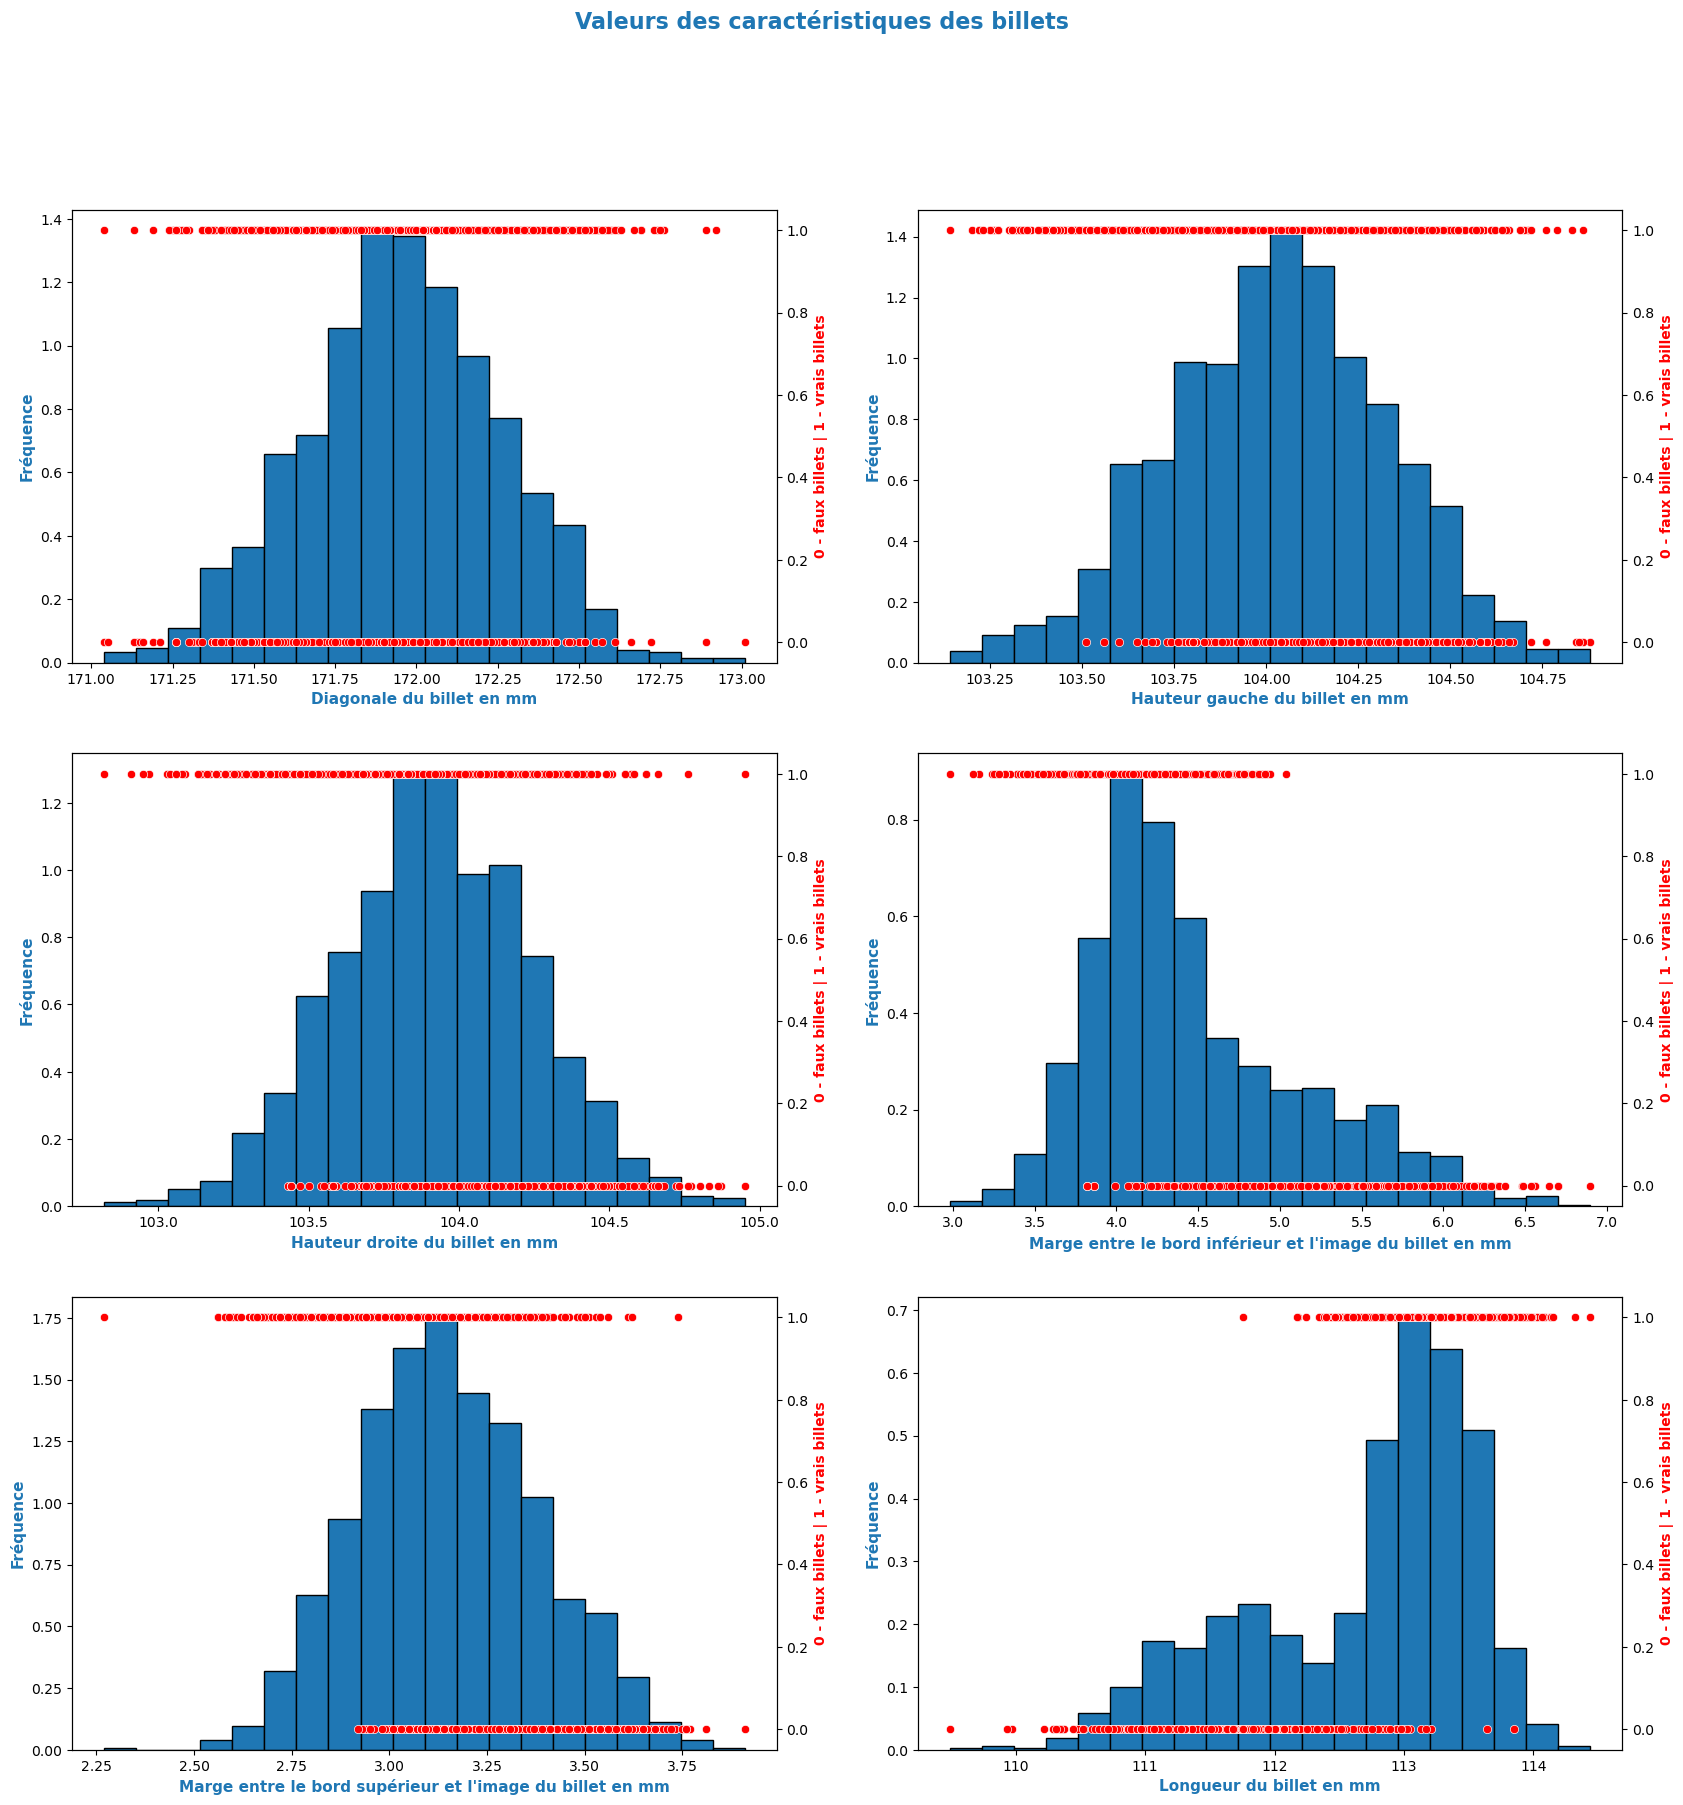

In [138]:
#Graphique représentant le distribution des caractéristiques des billets

fig, axes = plt.subplots(len(caracteristic_billets_nom) // 2,2)
fig.set_size_inches(20,20)

j= 0
for i, column in enumerate(caracteristic_billets_nom):
        
    axes[i // 2, j].hist(df_billets[column], bins=20, density=True, edgecolor='black')
    axes[i // 2, j].set_xlabel(map_caracteristiques_billets[column] + ' en mm', fontsize=11, color="#1F77B4", weight="bold")
    axes[i // 2, j].set_ylabel("Fréquence", fontsize=11, color="#1F77B4", weight="bold")

    # Création d'un axe secondaire
    ax_twin = axes[i // 2, j].twinx()
    sns.scatterplot(x=column, y='is_genuine', data=df_billets, ax=ax_twin, color='red', marker='o')
    ax_twin.set_ylabel('0 - faux billets | 1 - vrais billets', weight='bold', color='red',)

    if j == 0:
        j = j + 1
    else:
        j = 0

fig.suptitle("Valeurs des caractéristiques des billets", fontsize=16, color="#1F77B4", weight="bold")

plt.show()

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    Les vrais billets ont une marge inférieure comprise entre 3 et 5 mm et une longueur comprise entre 111,8 mm et 114,4 mm

</p>
</div>

In [139]:
map_caracteristiques_billets.values()

dict_values(['Diagonale du billet', 'Hauteur gauche du billet', 'Hauteur droite du billet', "Marge entre le bord inférieur et l'image du billet", "Marge entre le bord supérieur et l'image du billet", 'Longueur du billet', 'Type de billet'])

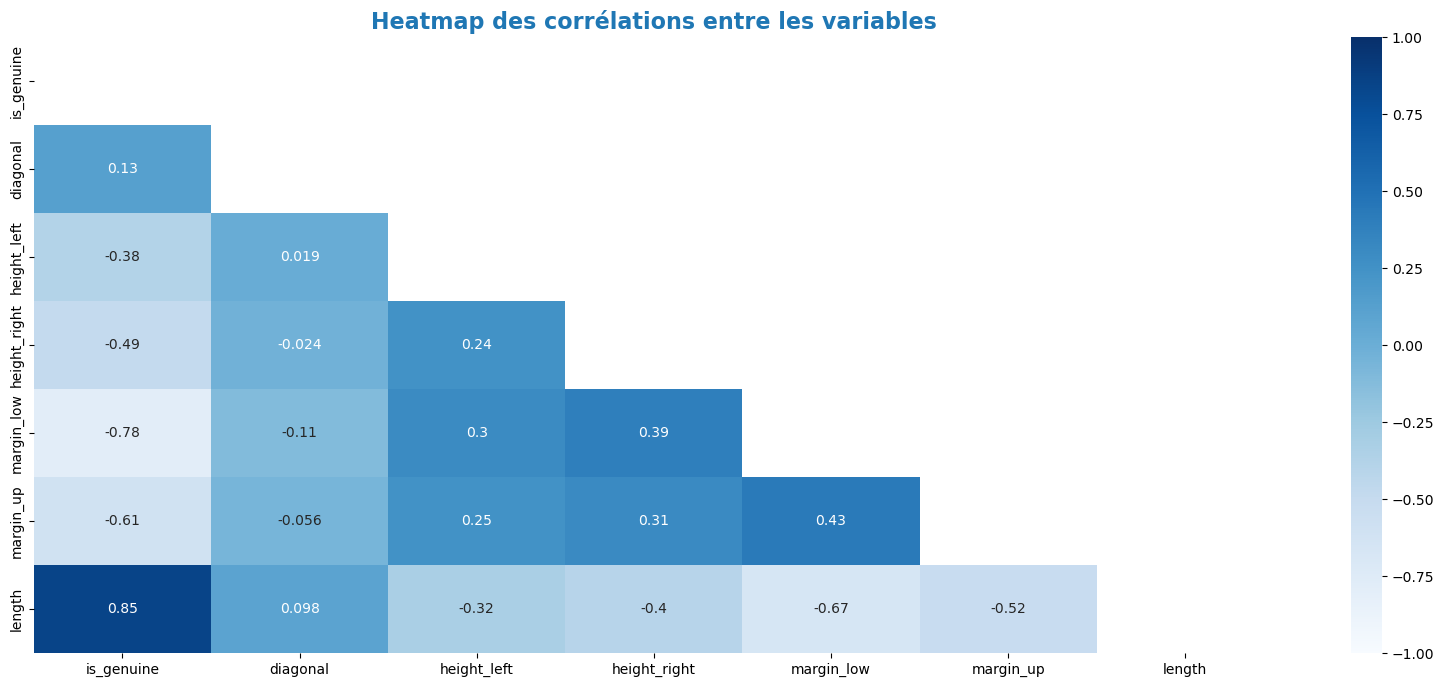

In [140]:
#Matrice de correlation

df_map_correlation = df_billets.corr()

df_merge_map_correlation_demi_map_correlation = np.triu(df_map_correlation)

plt.figure(figsize=(20, 8))
sns.heatmap(data = df_map_correlation, annot=True, center=0, mask=df_merge_map_correlation_demi_map_correlation, vmin=-1, vmax=1, cmap="Blues")
plt.title('Heatmap des corrélations entre les variables', fontsize=16, color="#1F77B4", weight="bold")

plt.show()

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    On constaste une corrélation entre les variables 
    <ul style="color: RGB(31,119,180);">
        <li>is_genuine et length</li>
        <li>is_genuine et margin_low</li>
        <li>margin_low et length</li>
    </ul>

</p>
</div>

<div style="background-color: RGB(31,119,180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Traitement des valeur vides de la colonne margin_low</h2>
</div>


<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">3.1 - Analyse bivariée</h3>
</div>

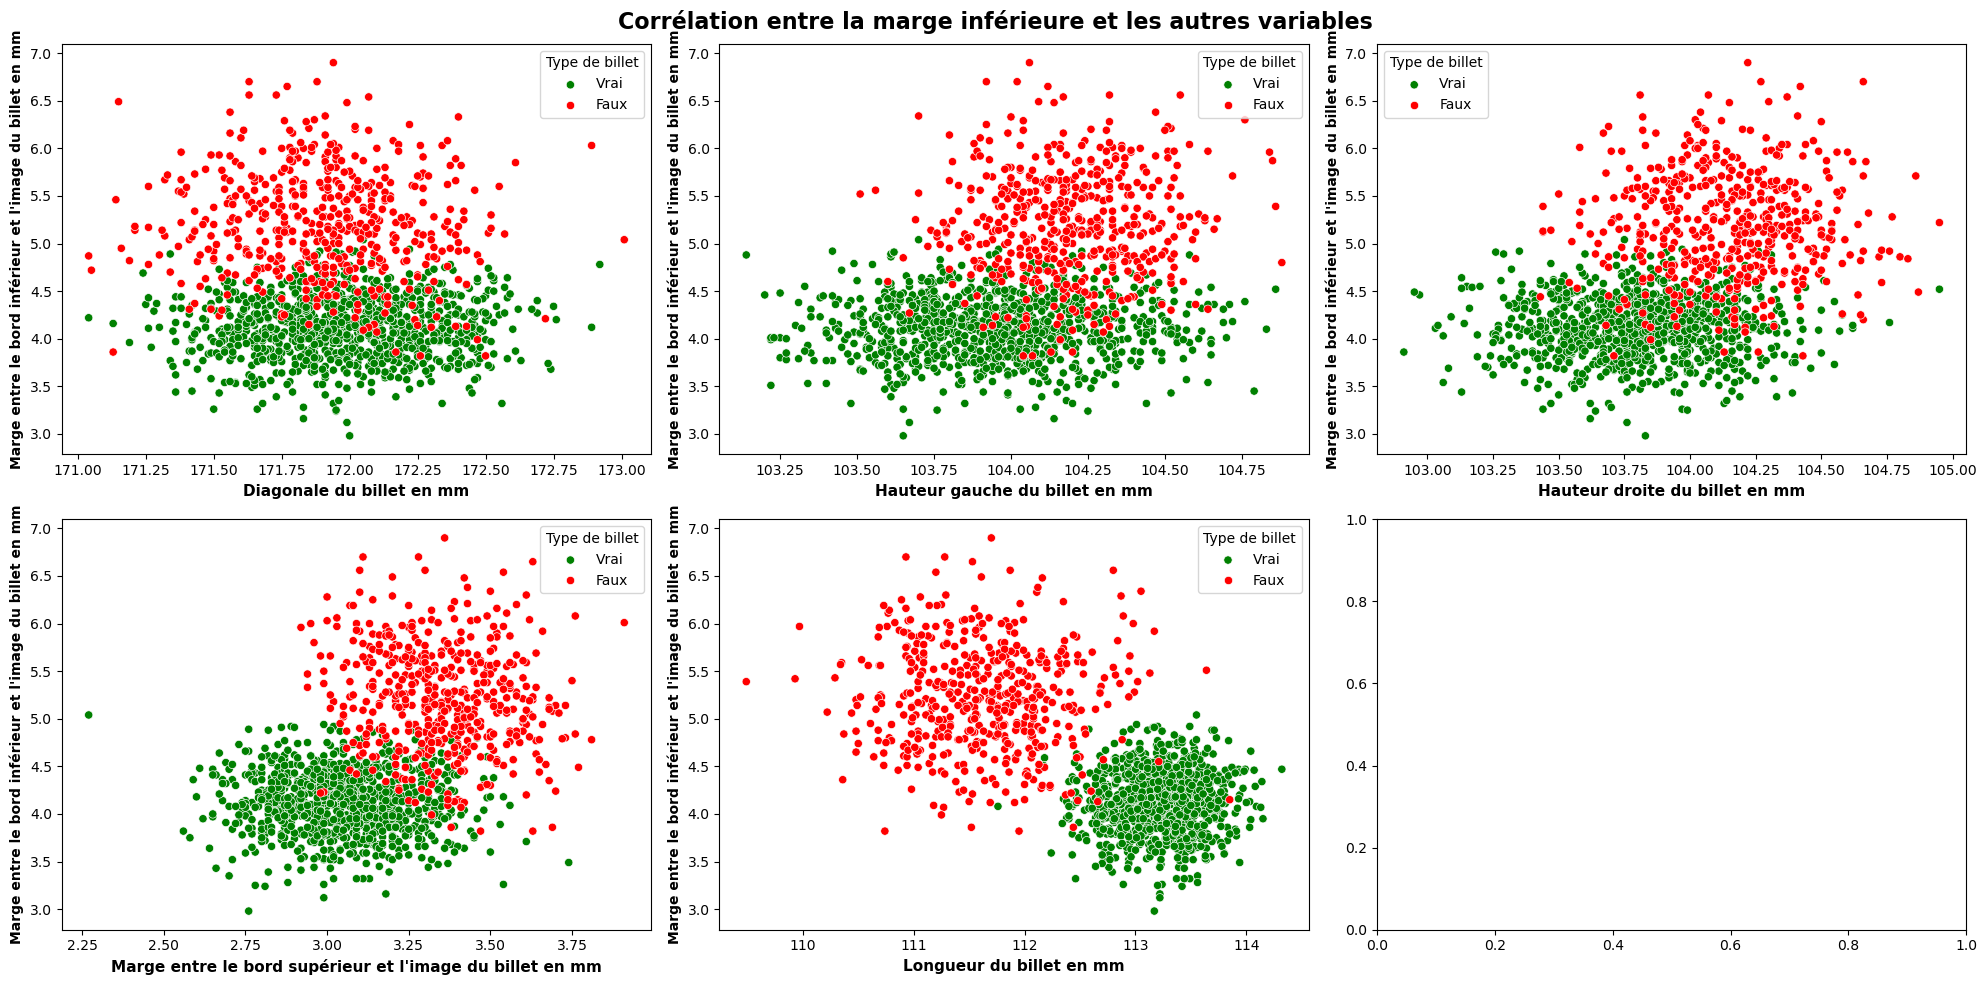

In [141]:
#Analyse bivariée entre la varaible margin_low et les autres variables
fig, axes = plt.subplots(2,3)
fig.set_size_inches(20, 10)

j= 0
for i, column in enumerate(caracteristic_billets_nom.drop("margin_low")):
    sns.scatterplot(data=df_billets, x = column, y = df_billets.margin_low, hue='is_genuine', ax=axes[i // 3, j], palette=["red","green"])
    axes[i // 3, j].set_ylabel(map_caracteristiques_billets["margin_low"]+ ' en mm', weight="bold")
    axes[i // 3, j].set_xlabel(map_caracteristiques_billets[column]+ ' en mm', fontsize=11, weight="bold")
    axes[i // 3, j].legend(title="Type de billet", loc="best", labels=["Vrai","Faux"])

    if j < 2:
        j = j + 1
    else:
        j = 0

fig.suptitle("Corrélation entre la marge inférieure et les autres variables", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    La corrélation est élevée entre la longueur du billet et la marge inférieure du billet et on disitingue 2 clusters distinct entre les vrais et les faux billets pour cette corrélation
</p>
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">3.2 - Régression linéaire stat model</h3>
</div>

In [142]:
#On garde les données qui ne sont pas vides
df_billets_not_missing_value = df_billets[df_billets['margin_low'].notna()]

X = df_billets_not_missing_value[['diagonal', 'height_left', 'height_right', 'margin_up', 'length']]
y = df_billets_not_missing_value.margin_low

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             margin_low   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     266.1
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          2.60e-202
Time:                        15:48:12   Log-Likelihood:                -1001.3
No. Observations:                1463   AIC:                             2015.
Df Residuals:                    1457   BIC:                             2046.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           22.9948      9.656      2.382      0.017       4.055      41.935
diagonal        -0.1111      0.041     -2.680      0.007      -0.192      -0.030
height_left      0.1841      0.045      4.113      0.000       0.096       0.272
height_right     0.2571      0.043      5.978      0.000       0.173       0.342
margin_up        0.2562      0.064      3.980      0.000       0.130       0.382
length          -0.4091      0.018    -22.627      0.000      -0.445      -0.374
==============================================================================
Omnibus:                       73.627   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               95.862
Skew:                           0.482   Prob(JB):                     1.53e-21
Kurtosis:                       3.801   Cond. No.                     1.94e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.94e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    Le R2 et le R2 ajusté sont moyens est moyen donc les prédictions moyennement fiables
    <br/>
    La probabilite de la F-statistic est inférieure à 0.05 donc le modèle est significatif
    <br/>
    Toutes les variables ont une p-value inférieure à 0.05 donc elles sont significatives
    <br/>
    Les variables length, margin_up et height_right sont les plus correlées à margin_low
    <br/>
    Cond. No. est très élevé donc certaines variables sont fortement corrélées entre elles
    <br/>
    Les p-value d'Omnibus est de 0 et le p-value de Jarque-Bera vaut 1.53e-21 donc les résidus ne suivent pas une loi normale
</p> 
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">3.3 - Régression linéaire simple - length</h3>
</div>

In [143]:
#On garde les données qui ne sont pas vides
df_billets_not_missing_value = df_billets[df_billets['margin_low'].notna()]

#Division du jeu de données en ensembles d'entraînement et de test
X = df_billets_not_missing_value[['length']]
y = df_billets_not_missing_value.margin_low
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [144]:
#Entrainement de la régression linéaire
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

LinearRegression()

In [145]:
#Prédictions du modele
y_test_pred = linear_regression.predict(X_test)
y_train_pred = linear_regression.predict(X_train)

In [146]:
#Coefficient linéaire
print("Coefficient linéaire entre la marge inférieur et la longeur du billet", round(linear_regression.coef_[0], 3))
print("Marge inférieur de base", round(linear_regression.intercept_, 3))

Coefficient linéaire entre la marge inférieur et la longeur du billet -0.499
Marge inférieur de base 60.705


In [147]:
#scores
train_score = linear_regression.score(X_train, y_train)
print('train score',round(train_score, 2))
test_score = linear_regression.score(X_test, y_test)
print('test score', round(test_score, 2))
train_r2_score = r2_score(y_train, y_train_pred)
test_r2_score = r2_score(y_test, y_test_pred)
print('train r2 score', round(train_r2_score, 2))
print('test r2 score', round(test_r2_score, 2))

print(f"RMSE test: {round(mean_squared_error(y_test, y_test_pred), 2)}")
print(f"MAPE test: {round(mean_absolute_percentage_error(y_test, y_test_pred), 2)}")

print(f"RMSE train: {round(mean_squared_error(y_train, y_train_pred), 2)}")
print(f"MAPE train: {round(mean_absolute_percentage_error(y_train, y_train_pred), 2)}")

train score 0.43
test score 0.51
train r2 score 0.43
test r2 score 0.51
RMSE test: 0.21
MAPE test: 0.08
RMSE train: 0.25
MAPE train: 0.09


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    Le train score est faible 0.43 donc la régression linéaire ne prédit pas bien les valeurs de la variable margin_low
    <br/>
    Le test score est supérieur au train score donc le modèle est en underfitting
    <br/>
    Le R2 est moyen donc les prédictions moyennement fiables
    <br/>
    Les scores MAPE et RMSE sont faible ce qui veut dire donc la régression linéaire fait peu d'erreur
</p> 
</div>

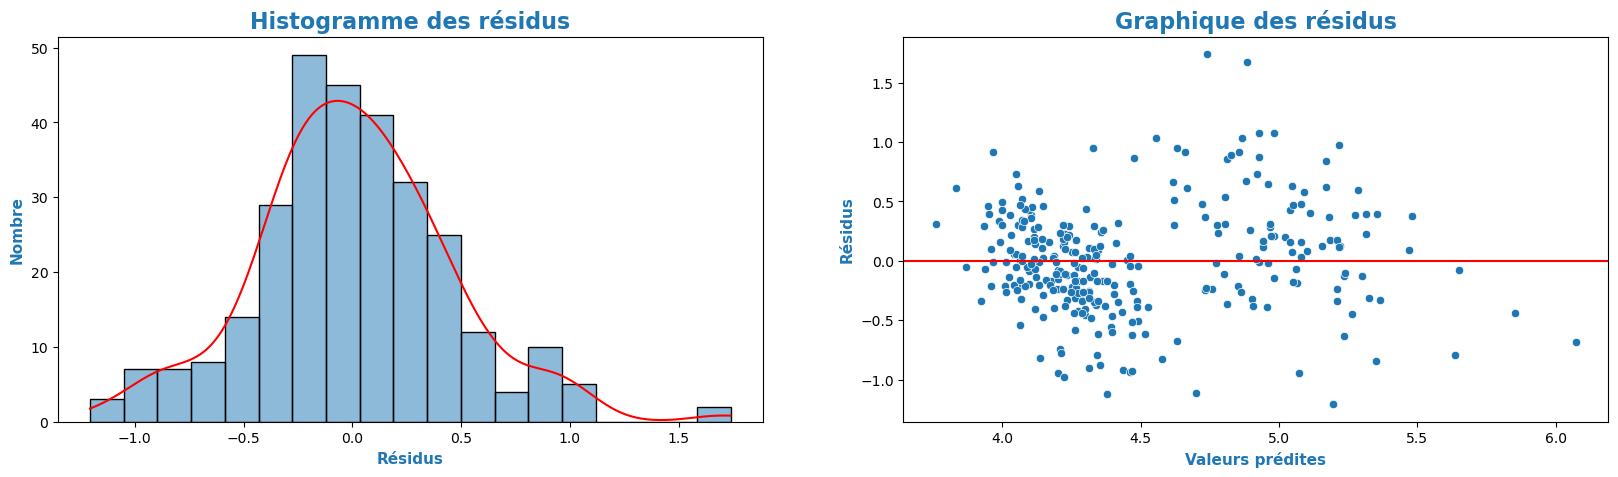

In [148]:
# Calcul des résidus
residuals = y_test - y_test_pred

fig,axes = plt.subplots(1,2)
fig.set_size_inches(20, 5)

# Histogramme des résidus
sns.histplot(x=residuals, kde=True, ax=axes[0], stat='count')
axes[0].lines[0].set_color('red')
axes[0].set_title("Histogramme des résidus", fontsize=16, color="#1F77B4", weight="bold")
axes[0].set_xlabel("Résidus", fontsize=11, color="#1F77B4", weight="bold")
axes[0].set_ylabel("Nombre", fontsize=11, color="#1F77B4", weight="bold")

# Graphique des résidus pour vérifier l'hétéroscédasticité
sns.scatterplot(x=y_test_pred, y=residuals, ax=axes[1])
axes[1].axhline(y=0, color='r')
axes[1].set_title("Graphique des résidus", fontsize=16, color="#1F77B4", weight="bold")
axes[1].set_xlabel("Valeurs prédites", fontsize=11, color="#1F77B4", weight="bold")
axes[1].set_ylabel("Résidus", fontsize=11, color="#1F77B4", weight="bold")

plt.show()


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    L'histogramme des résidus ne suit pas une loi normale
    <br/>
    Le graphique des résidus montre que les résidus ne se concentrent pas autour de 0
</p> 
</div>

In [149]:
#Test de normalité des résidus avec Shapiro-Wilk
stat, p_value = stats.shapiro(residuals)
print(f"Statistique de Shapiro-Wilk : {stat}, p-value : {p_value}")

Statistique de Shapiro-Wilk : 0.9842709989575223, p-value : 0.0026657159530572264


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    D'après le test de Shapiro-Wilk p-value est inférieur à 0,05 donc on rejette l’hypothèse de normalité des résidus
</p> 
</div>

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    D'après les tests ci-dessus on ne peut pas déterminer la valeur de la marge inférieure à partir de la longueur du billet
</p> 
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">3.4 - Régression linéaire multiple - toutes les variables</h3>
</div>

In [150]:
# Diviser le jeu de données en ensembles d'entraînement et de test
X = df_billets_not_missing_value[['diagonal', 'height_left', 'height_right', 'margin_up', 'length']]
y = df_billets_not_missing_value.margin_low
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [151]:
#Entrainement de la régression linéaire
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

LinearRegression()

In [152]:
#Prédiction de la régression linéaire
y_test_pred = linear_regression.predict(X_test)
y_train_pred = linear_regression.predict(X_train)

In [153]:
#Map contenant le coefficient par variable
map_coeff_linear_reg = {}
for i,column in enumerate(X.columns):
    map_coeff_linear_reg[column] = round(linear_regression.coef_[i], 3)

print("Coefficient par variable")
map_coeff_linear_reg

Coefficient par variable


{'diagonal': -0.087,
 'height_left': 0.155,
 'height_right': 0.26,
 'margin_up': 0.291,
 'length': -0.399}

In [154]:
#Coefficient linéaire
print("Coefficient linéaire entre la marge inférieur et les autres variables")
df_coeff_lineaire = pd.DataFrame(index=[0], data=map_coeff_linear_reg)
display(df_coeff_lineaire)
print("Marge inférieur de base", round(linear_regression.intercept_, 2))

Coefficient linéaire entre la marge inférieur et les autres variables


,diagonal,height_left,height_right,margin_up,length
0,-0.087,0.155,0.26,0.291,-0.399


Marge inférieur de base 20.4


In [155]:
#scores
train_score = linear_regression.score(X_train, y_train)
print('train score',round(train_score, 2))
test_score = linear_regression.score(X_test, y_test)
print('test score', round(test_score, 2))
train_r2_score = r2_score(y_train, y_train_pred)
test_r2_score = r2_score(y_test, y_test_pred)
print('test r2 score', round(train_r2_score, 2))
print('test r2 score', round(test_r2_score, 2))


print(f"RMSE test: {round(mean_squared_error(y_test, y_test_pred), 2)}")
print(f"MAPE test: {round(mean_absolute_percentage_error(y_test, y_test_pred), 2)}")

print(f"RMSE train: {round(mean_squared_error(y_train, y_train_pred), 2)}")
print(f"MAPE train: {round(mean_absolute_percentage_error(y_train, y_train_pred), 2)}")


train score 0.46
test score 0.55
test r2 score 0.46
test r2 score 0.55
RMSE test: 0.19
MAPE test: 0.07
RMSE train: 0.24
MAPE train: 0.08


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    Les train et test score et R2 sont plus elevé que ceux de la 1ere regression linéaire
    <br />
    Le train score est faible 0.46 donc la régression linéaire ne prédit pas bien les valeurs de la variable margin_low
    <br/>
    Le test score est supérieur au train score donc le modèle est en underfitting
    <br/>
    Le R2 est moyen donc les prédictions moyennement fiables
    <br/>
    Les scores MAPE et RMSE sont faible ce qui veut dire donc la régression linéaire fait peu d'erreur et ils sont plus faibles que la 1ere régression linéeaire
    <br />
    Bien que la régression linéaire multiple soit plus fiable que le régression linéaire simple, celle-ci n'est pas fiable pour le determination de la valeur de la variable margin_low
</p> 
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">3.3 - Normalité des résidus</h3>
</div>

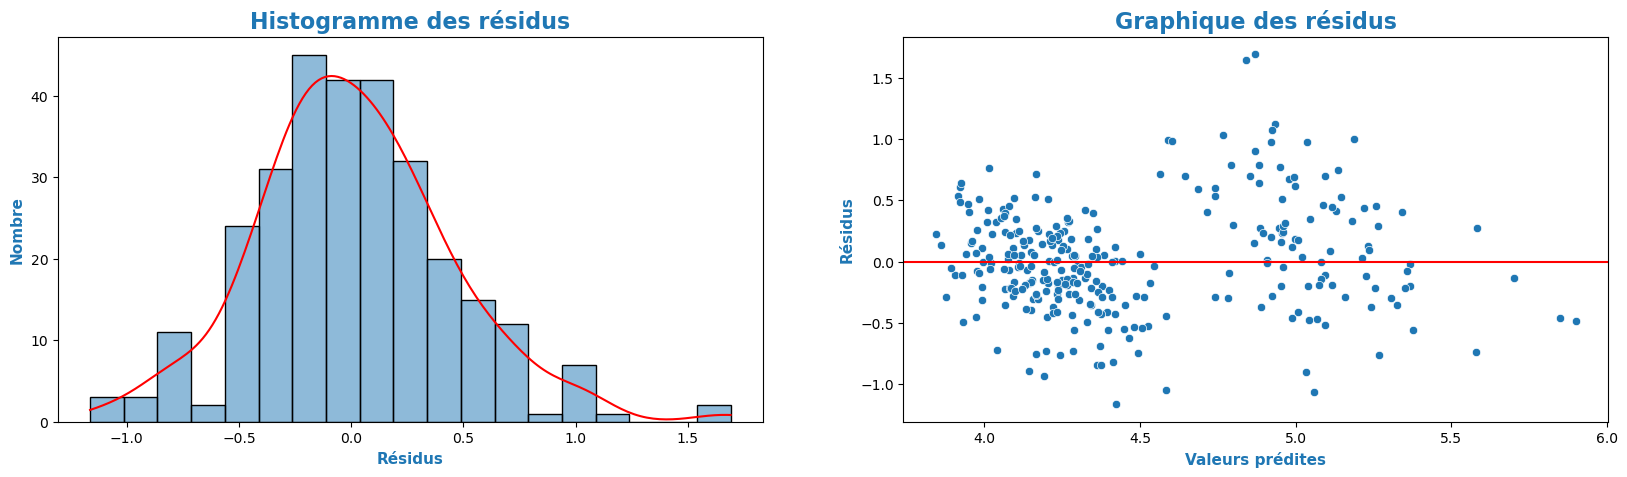

In [156]:
# Calcul des résidus
residuals = y_test - y_test_pred

fig,axes = plt.subplots(1,2)
fig.set_size_inches(20, 5)

# Histogramme des résidus
sns.histplot(x=residuals, kde=True, ax=axes[0], stat='count')
axes[0].lines[0].set_color('red')
axes[0].set_title("Histogramme des résidus", fontsize=16, color="#1F77B4", weight="bold")
axes[0].set_xlabel("Résidus", fontsize=11, color="#1F77B4", weight="bold")
axes[0].set_ylabel("Nombre", fontsize=11, color="#1F77B4", weight="bold")

# Graphique des résidus pour vérifier l'hétéroscédasticité
sns.scatterplot(x=y_test_pred, y=residuals, ax=axes[1])
axes[1].axhline(y=0, color='r')
axes[1].set_title("Graphique des résidus", fontsize=16, color="#1F77B4", weight="bold")
axes[1].set_xlabel("Valeurs prédites", fontsize=11, color="#1F77B4", weight="bold")
axes[1].set_ylabel("Résidus", fontsize=11, color="#1F77B4", weight="bold")

plt.show()


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    L'histogramme des résidus ne suit pas une loi normale
    <br/>
    Le graphique des résidus montre que les résidus ne se concentrent pas autour de 0
</p> 
</div>

In [157]:
#Test de normalité des résidus avec Shapiro-Wilk
stat, p_value = stats.shapiro(residuals)
print(f"Statistique de Shapiro-Wilk : {stat}, p-value : {p_value}")

Statistique de Shapiro-Wilk : 0.9850901433257552, p-value : 0.0038966834213477438


<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    D'après le test de Shapiro-Wilk p-value est inférieur à 0,05 donc on rejette l’hypothèse de normalité des résidus
</p> 
</div>

<div>
<p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
    D'après les tests ci-dessus on ne peut pas déterminer la valeur de la marge inférieure à des caractéristiques des billets
</p> 
</div>

<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        La valeur de la marge inférieure ne peut être déduite des autres caractéristiques des billets donc on supprime les lignes contenant des marges inférieures vides
    </p>
</div>

<div style="background-color: RGB(31,119,180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Prétraitement</h2>
</div>


In [158]:
#Ajout d'un colonne contenant l'authenticité d'un billet avec les valeur 0 et 1
df_billets['is_genuine_int'] =df_billets['is_genuine'].apply(
    lambda x: 1 if x is True else 0
)
df_billets.head()


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_int
0,True,171.81,104.86,104.95,4.52,2.89,112.83,1
1,True,171.46,103.36,103.66,3.77,2.99,113.09,1
2,True,172.69,104.48,103.50,4.40,2.94,113.16,1
3,True,171.36,103.91,103.94,3.62,3.01,113.51,1
4,True,171.73,104.28,103.46,4.04,3.48,112.54,1


In [159]:
#On supprime les lignes qui ne sont pas renseignées
df_billets_not_missing_value = df_billets[df_billets['margin_low'].notna()]

In [160]:
#X contient les caractéristiques des billets
#y contient les valeurs de la colonne is_geniune_int
x_columns = df_billets_not_missing_value.columns.drop(["is_genuine", "is_genuine_int"])
X = df_billets_not_missing_value[x_columns]
y = df_billets_not_missing_value.is_genuine_int

In [161]:
#On divise le jeu de donnée en 2
#80% pour l'entrainement, 20% pour le test et on a la même proportion de la variable is_geniune dans le jeu de donnée
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y) 

In [162]:
#Normalistation des données X_train et X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<div style="background-color: RGB(31,119,180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Modélisation</h2>
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">4.1 - Régression Logistique</h3>
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">4.1.1 - Régression Logistique - Sans optimisation</h3>
</div>

train score 0.9931623931623932
test score 0.9897610921501706
accuracy 0.9897610921501706
precision 0.9847715736040609
recall 1.0
f1-score 0.9923273657289002


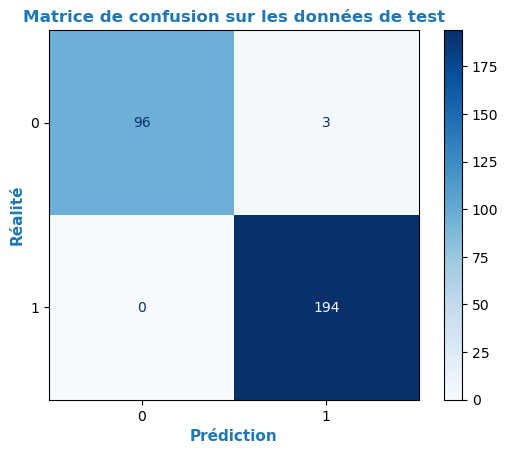

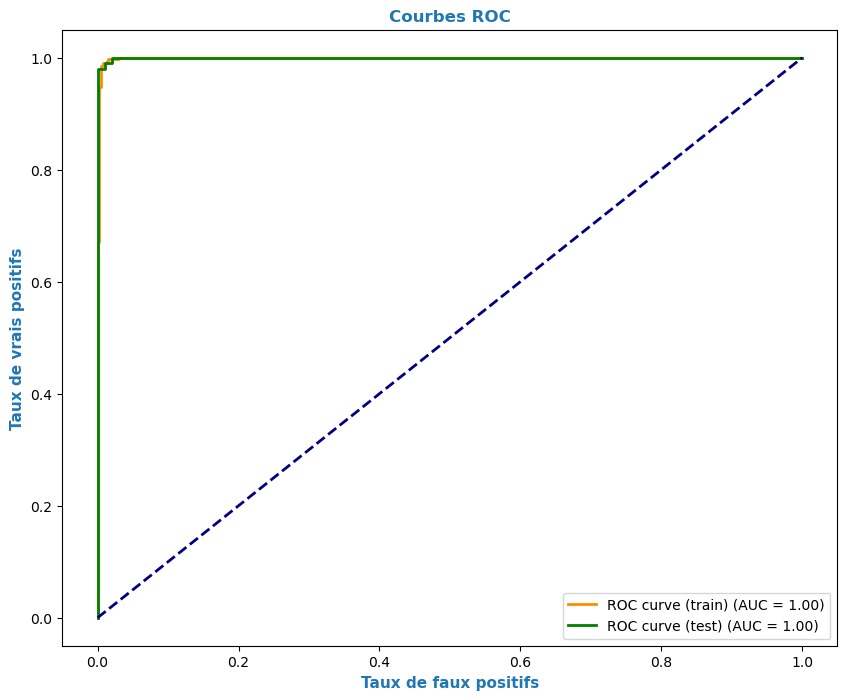

In [163]:
#Initialisation de la regression logistique
logisiticRegression = LogisticRegression(random_state=42, max_iter=100)

#Entrainement du modèle
clf = logisiticRegression.fit(X_train_scaled, y_train)

# predictions 
y_test_pred = logisiticRegression.predict(X_test_scaled)
y_train_pred = logisiticRegression.predict(X_train_scaled)

#scores
train_score = logisiticRegression.score(X_train_scaled, y_train)
print('train score',train_score)
test_score = logisiticRegression.score(X_test_scaled, y_test)
print('test score',test_score)

print("accuracy",accuracy_score(y_test, y_test_pred))
print("precision",precision_score(y_test, y_test_pred))
print("recall",recall_score(y_test, y_test_pred))
print("f1-score",f1_score(y_test, y_test_pred))

#Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues')
cm_display.ax_.set_title("Matrice de confusion sur les données de test", fontsize=12, color="#1F77B4", weight="bold")
cm_display.ax_.set_xlabel('Prédiction', fontsize=11, color="#1F77B4", weight="bold");
cm_display.ax_.set_ylabel('Réalité', fontsize=11, color="#1F77B4", weight="bold"); 
plt.show()

#Courbes ROC
y_test_proba = logisiticRegression.predict_proba(X_test_scaled)[:,1]
y_train_proba = logisiticRegression.predict_proba(X_train_scaled)[:,1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)


plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color="darkorange", lw=2, label="ROC curve (train) (AUC = %0.2f)" % roc_auc_train)
plt.plot(fpr_test, tpr_test, color="green", lw=2, label="ROC curve (test) (AUC = %0.2f)" % roc_auc_test)
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle='--')
plt.xlabel("Taux de faux positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.ylabel("Taux de vrais positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.title("Courbes ROC", fontsize=12, color="#1F77B4", weight="bold")
plt.legend(loc="lower right")
plt.show()


In [164]:
#Sauvegarde des scores dans un dataframe

map_score = {
    "train score": train_score,
    "accuracy":accuracy_score(y_test, y_test_pred),
    "precision":precision_score(y_test, y_test_pred),
    "recall":recall_score(y_test, y_test_pred),
    "f1-score":f1_score(y_test, y_test_pred),
    "ROC":roc_auc_test,
    "Faux positif":3,
    "Faux négatifs":0
}


df_scores_modeles = pd.DataFrame(index=["Régression logistique"], data=map_score)
df_scores_modeles

,train score,accuracy,precision,recall,f1-score,ROC,Faux positif,Faux négatifs
Régression logistique,0.993162,0.989761,0.984772,1.0,0.992327,0.999688,3,0


<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">4.1.2 - Régression Logistique - Avec optimisation</h3>
</div>

In [165]:
param_grid = {
    'max_iter' : [150, 200, 250, 300, 350, 400, 450],
    "penalty":["l2"],
    "C": [0.01, 0.1, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "solver": ["lbfgs"]
}

logisiticRegression = LogisticRegression(random_state=42)

grid_search = GridSearchCV(logisiticRegression, param_grid, cv=5)
grid_search.fit(X_train, y_train)

#Affichage des meilleurs paramètres
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleurs paramètres : {'C': 4, 'max_iter': 150, 'penalty': 'l2', 'solver': 'lbfgs'}


train score 0.9931623931623932
test score 0.9863481228668942
accuracy 0.9863481228668942
precision 0.9846938775510204
recall 0.9948453608247423
f1-score 0.9897435897435898


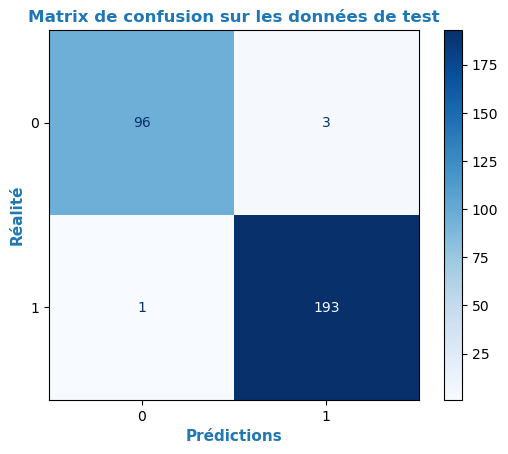

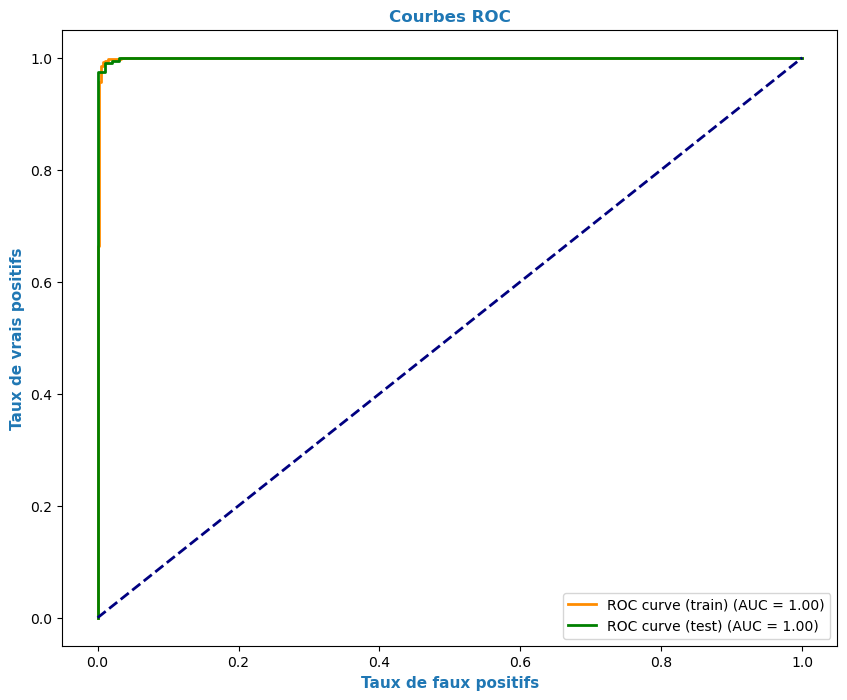

In [166]:
#Initialisation de la régression logisitique avec les valeur optimales
logisiticRegression =  grid_search.best_estimator_
#Entrainement du modèle
clf = logisiticRegression.fit(X_train_scaled, y_train)

# predictions 
y_test_pred = logisiticRegression.predict(X_test_scaled)
y_train_pred = logisiticRegression.predict(X_train_scaled)

#scores
train_score = logisiticRegression.score(X_train_scaled, y_train)
print('train score',train_score)
test_score = logisiticRegression.score(X_test_scaled, y_test)
print('test score',test_score)
print("accuracy",accuracy_score(y_test, y_test_pred))
print("precision",precision_score(y_test, y_test_pred))
print("recall",recall_score(y_test, y_test_pred))
print("f1-score",f1_score(y_test, y_test_pred))

#Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues')
cm_display.ax_.set_title("Matrix de confusion sur les données de test", fontsize=12, color="#1F77B4", weight="bold")
cm_display.ax_.set_xlabel('Prédictions', fontsize=11, color="#1F77B4", weight="bold");
cm_display.ax_.set_ylabel('Réalité', fontsize=11, color="#1F77B4", weight="bold"); 
plt.show()

#Courbes ROC
y_test_proba = logisiticRegression.predict_proba(X_test_scaled)[:,1]
y_train_proba = logisiticRegression.predict_proba(X_train_scaled)[:,1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)


plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color="darkorange", lw=2, label="ROC curve (train) (AUC = %0.2f)" % roc_auc_train)
plt.plot(fpr_test, tpr_test, color="green", lw=2, label="ROC curve (test) (AUC = %0.2f)" % roc_auc_test)
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle='--')
plt.xlabel("Taux de faux positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.ylabel("Taux de vrais positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.title("Courbes ROC", fontsize=12, color="#1F77B4", weight="bold")
plt.legend(loc="lower right")
plt.show()


In [167]:
#Sauvegarde des scores dans un dataframe

map_score = {
    "train score": train_score,
    "accuracy":accuracy_score(y_test, y_test_pred),
    "precision":precision_score(y_test, y_test_pred),
    "recall":recall_score(y_test, y_test_pred),
    "f1-score":f1_score(y_test, y_test_pred),
    "ROC":roc_auc_test,
    "Faux positif":3,
    "Faux négatifs":1
}


df_scores_modeles.loc["Régression logistique optimisées"] = map_score
df_scores_modeles

,train score,accuracy,precision,recall,f1-score,ROC,Faux positif,Faux négatifs
Régression logistique,0.993162,0.989761,0.984772,1.000000,0.992327,0.999688,3,0
Régression logistique optimisées,0.993162,0.986348,0.984694,0.994845,0.989744,0.999583,3,1


<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        L'algorithme de regression logisitique donne de meilleurs scores lorsqu'il n'est pas optimisé
    </p>
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">4.2 - K-nearest neighbors</h3>
</div>

In [168]:
#Recherche du nombre de voisin le plus proche optimal
#Liste des valeurs de k à tester
k_values = list(range(1, 30))

#Création de l'instance du classificateur KNN
knn = KNeighborsClassifier()

#paramètre pour la recherche de grille
param_grid = {"n_neighbors": k_values}

#Recherhce de grille avec la validation croisée
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

#Extraction des scores de validation croisée et des valeurs de k correspondantes
cv_scores = grid_search.cv_results_["mean_test_score"]
print("Scores de validation croisée",cv_scores )

best_k= grid_search.best_params_["n_neighbors"]
print("\n Meilleur valeur de k", best_k)


Scores de validation croisée [0.98717949 0.98803419 0.99059829 0.98974359 0.99145299 0.98974359
 0.99059829 0.98974359 0.99059829 0.98974359 0.98974359 0.98974359
 0.98974359 0.99059829 0.98974359 0.99059829 0.98888889 0.98803419
 0.98803419 0.98888889 0.98888889 0.98888889 0.98974359 0.98888889
 0.98888889 0.98888889 0.98803419 0.98888889 0.98803419]

 Meilleur valeur de k 5


<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        La moyenne des scores obtenu pour chaque fold est compris entre 0.98 et 0.99 donc les fold sont à peu près équivalent
        <br />
        Le nombre de voisin optimal est de 5
    </p>
</div>

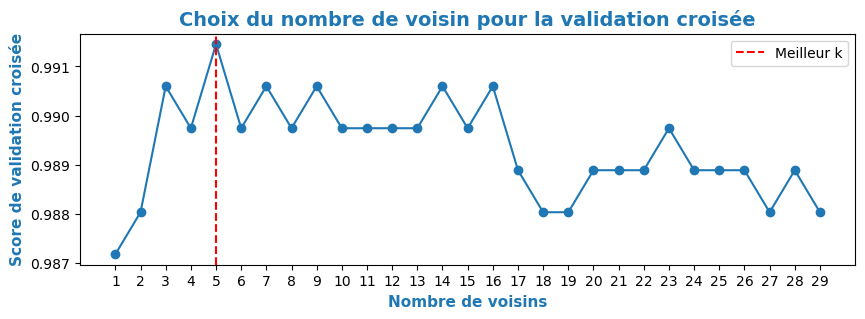

In [169]:
#Graphique des scores de validation croisé en fonction de k
plt.figure(figsize=(10, 3))
plt.plot(k_values, cv_scores, "-o")
plt.xlabel("Nombre de voisins", fontsize=11, color="#1F77B4", weight="bold")
plt.ylabel("Score de validation croisée", fontsize=11, color="#1F77B4", weight="bold")
plt.title("Choix du nombre de voisin pour la validation croisée", fontsize=14, color="#1F77B4", weight="bold")
plt.xticks(k_values)
plt.axvline(x=best_k, color='red', linestyle='--', label ="Meilleur k")
plt.legend()
plt.show()


train score 0.994017094017094
test score 0.9829351535836177
accuracy 0.9829351535836177
precision 0.9748743718592965
recall 1.0
f1-score 0.9872773536895675


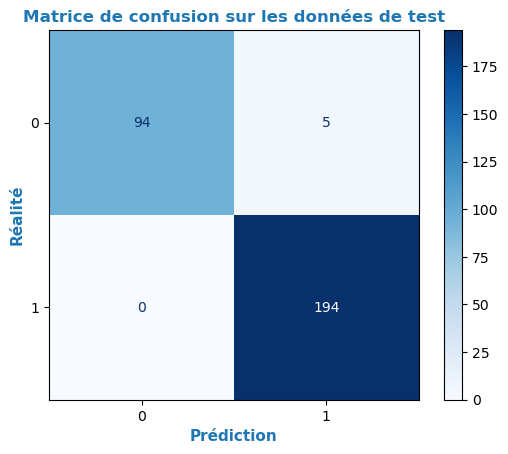

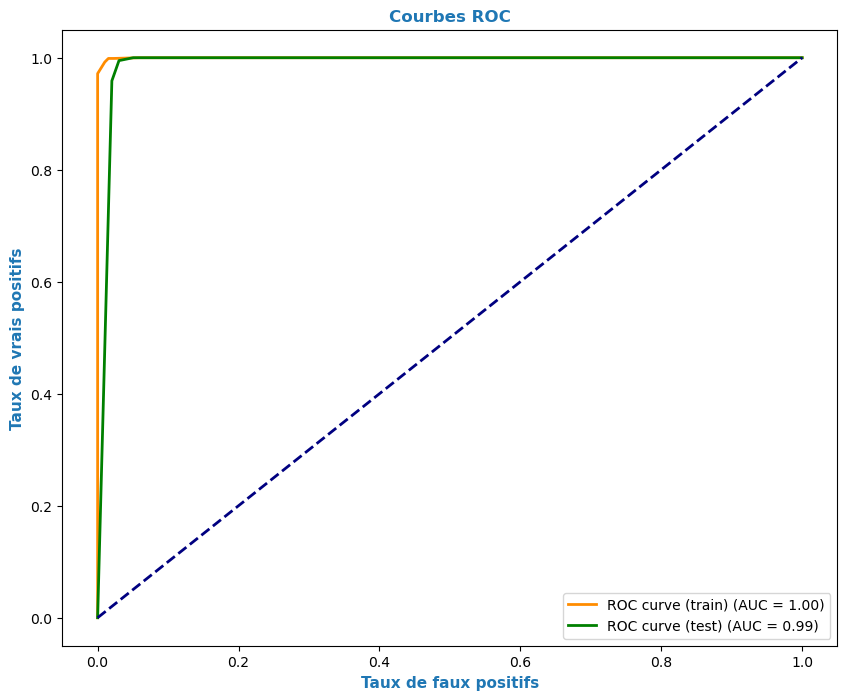

In [170]:
#Initialisation du knn
knn = grid_search.best_estimator_

#Entrainement du modèle
knn.fit(X_train_scaled, y_train)

# predictions 
y_test_pred = knn.predict(X_test_scaled)
y_train_pred = knn.predict(X_train_scaled)

#scores
train_score = knn.score(X_train_scaled, y_train)
print('train score',train_score)
test_score = knn.score(X_test_scaled, y_test)
print('test score',test_score)
print("accuracy",accuracy_score(y_test, y_test_pred))
print("precision",precision_score(y_test, y_test_pred))
print("recall",recall_score(y_test, y_test_pred))
print("f1-score",f1_score(y_test, y_test_pred))

#Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues')
cm_display.ax_.set_title("Matrice de confusion sur les données de test", fontsize=12, color="#1F77B4", weight="bold")
cm_display.ax_.set_xlabel('Prédiction', fontsize=11, color="#1F77B4", weight="bold");
cm_display.ax_.set_ylabel('Réalité', fontsize=11, color="#1F77B4", weight="bold"); 
plt.show()

#Courbes ROC
y_test_proba = knn.predict_proba(X_test_scaled)[:,1]
y_train_proba = knn.predict_proba(X_train_scaled)[:,1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)


plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color="darkorange", lw=2, label="ROC curve (train) (AUC = %0.2f)" % roc_auc_train)
plt.plot(fpr_test, tpr_test, color="green", lw=2, label="ROC curve (test) (AUC = %0.2f)" % roc_auc_test)
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle='--')
plt.xlabel("Taux de faux positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.ylabel("Taux de vrais positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.title("Courbes ROC", fontsize=12, color="#1F77B4", weight="bold")
plt.legend(loc="lower right")
plt.show()

<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        L'algorithme KNN donne des scores proche de 1
    </p>
</div>

In [171]:
#Sauvegarde des scores dans un dataframe

map_score = {
    "train score": train_score,
    "accuracy":accuracy_score(y_test, y_test_pred),
    "precision":precision_score(y_test, y_test_pred),
    "recall":recall_score(y_test, y_test_pred),
    "f1-score":f1_score(y_test, y_test_pred),
    "ROC":roc_auc_test,
    "Faux positif":5,
    "Faux négatifs":0
}


df_scores_modeles.loc["KNN"] = map_score
df_scores_modeles

,train score,accuracy,precision,recall,f1-score,ROC,Faux positif,Faux négatifs
Régression logistique,0.993162,0.989761,0.984772,1.000000,0.992327,0.999688,3,0
Régression logistique optimisées,0.993162,0.986348,0.984694,0.994845,0.989744,0.999583,3,1
KNN,0.994017,0.982935,0.974874,1.000000,0.987277,0.989196,5,0


<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">4.3 - RandomForestClassifier</h3>
</div>

<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">4.3.1 - RandomForestClassifier - Sans optimisation</h3>
</div>

train score 1.0
test score 0.9897610921501706
accuracy 0.9897610921501706
precision 0.9847715736040609
recall 1.0
f1-score 0.9923273657289002


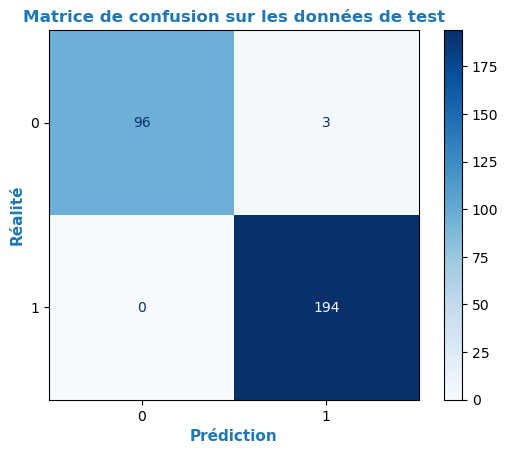

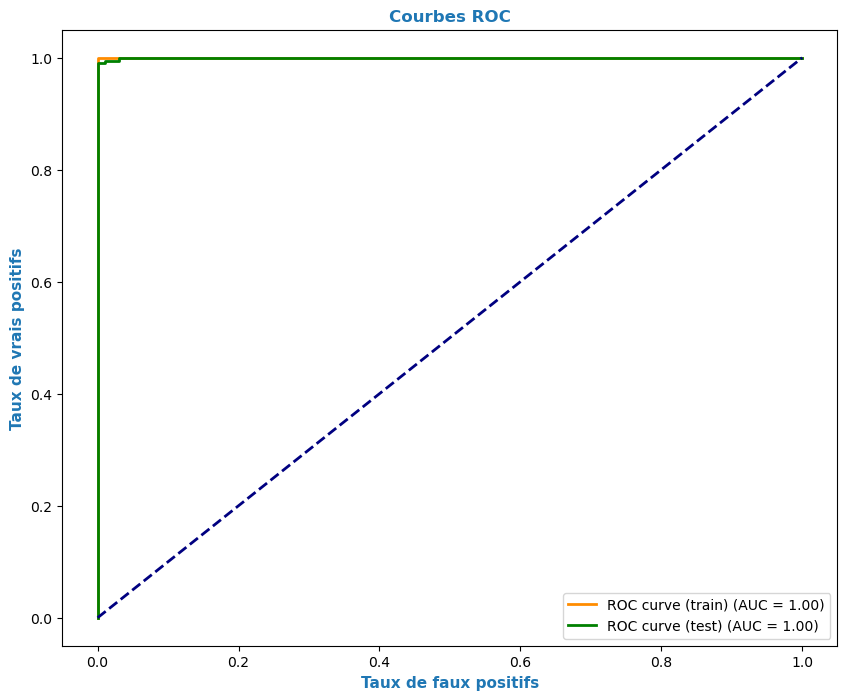

In [172]:
#Initialisation du modèle
randomForestClassifier = RandomForestClassifier(random_state=42)

#Entrainement du modèle
randomForestClassifier.fit(X_train, y_train)

#Prédictions du modèle
y_test_pred = randomForestClassifier.predict(X_test)
y_train_pred = randomForestClassifier.predict(X_train)

#Scores
train_score = randomForestClassifier.score(X_train, y_train)
print('train score',train_score)
test_score = randomForestClassifier.score(X_test, y_test)
print('test score',test_score)

print("accuracy",accuracy_score(y_test, y_test_pred))
print("precision",precision_score(y_test, y_test_pred))
print("recall",recall_score(y_test, y_test_pred))
print("f1-score",f1_score(y_test, y_test_pred))

#Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred, labels=randomForestClassifier.classes_)
cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap='Blues')
cm_display.ax_.set_title("Matrice de confusion sur les données de test", fontsize=12, color="#1F77B4", weight="bold")
cm_display.ax_.set_xlabel('Prédiction', fontsize=11, color="#1F77B4", weight="bold");
cm_display.ax_.set_ylabel('Réalité', fontsize=11, color="#1F77B4", weight="bold"); 
plt.show()

#Courbes ROC
y_train_proba = randomForestClassifier.predict_proba(X_train)[:,1]
y_test_proba = randomForestClassifier.predict_proba(X_test)[:,1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color="darkorange", lw=2, label="ROC curve (train) (AUC = %0.2f)" % roc_auc_train)
plt.plot(fpr_test, tpr_test, color="green", lw=2, label="ROC curve (test) (AUC = %0.2f)" % roc_auc_test)
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle='--')
plt.xlabel("Taux de faux positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.ylabel("Taux de vrais positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.title("Courbes ROC", fontsize=12, color="#1F77B4", weight="bold")
plt.legend(loc="lower right")
plt.show()

In [173]:
#Sauvegarde des scores dans un dataframe

map_score = {
    "train score": train_score,
    "accuracy":accuracy_score(y_test, y_test_pred),
    "precision":precision_score(y_test, y_test_pred),
    "recall":recall_score(y_test, y_test_pred),
    "f1-score":f1_score(y_test, y_test_pred),
    "ROC":roc_auc_test,
    "Faux positif":3,
    "Faux négatifs":0
}


df_scores_modeles.loc["Random Forest"] = map_score
df_scores_modeles

,train score,accuracy,precision,recall,f1-score,ROC,Faux positif,Faux négatifs
Régression logistique,0.993162,0.989761,0.984772,1.000000,0.992327,0.999688,3,0
Régression logistique optimisées,0.993162,0.986348,0.984694,0.994845,0.989744,0.999583,3,1
KNN,0.994017,0.982935,0.974874,1.000000,0.987277,0.989196,5,0
Random Forest,1.000000,0.989761,0.984772,1.000000,0.992327,0.999792,3,0


<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">4.3.2 - RandomForestClassifier - Avec optimisation</h3>
</div>

In [174]:
param_grid = {
    'n_estimators' : [10,15,20,25,30,40,50, 60, 70, 80, 90, 100, 110, 120],
    'max_depth': [1,2,3,4,5,6,7,8]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(rf_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

#Affichage des meilleurs paramètres
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleurs paramètres : {'max_depth': 7, 'n_estimators': 25}


train score 1.0
test score 0.9897610921501706
precision 0.9847715736040609
recall 1.0
f1-score 0.9923273657289002


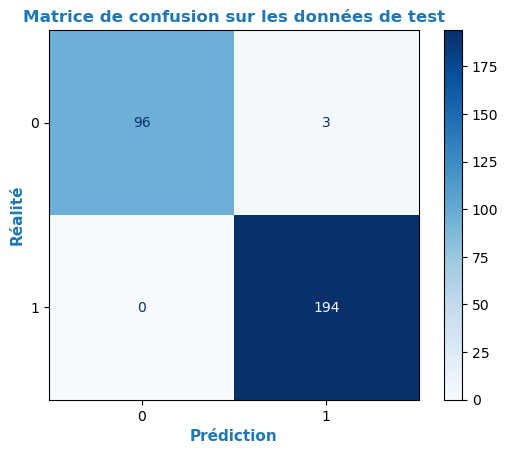

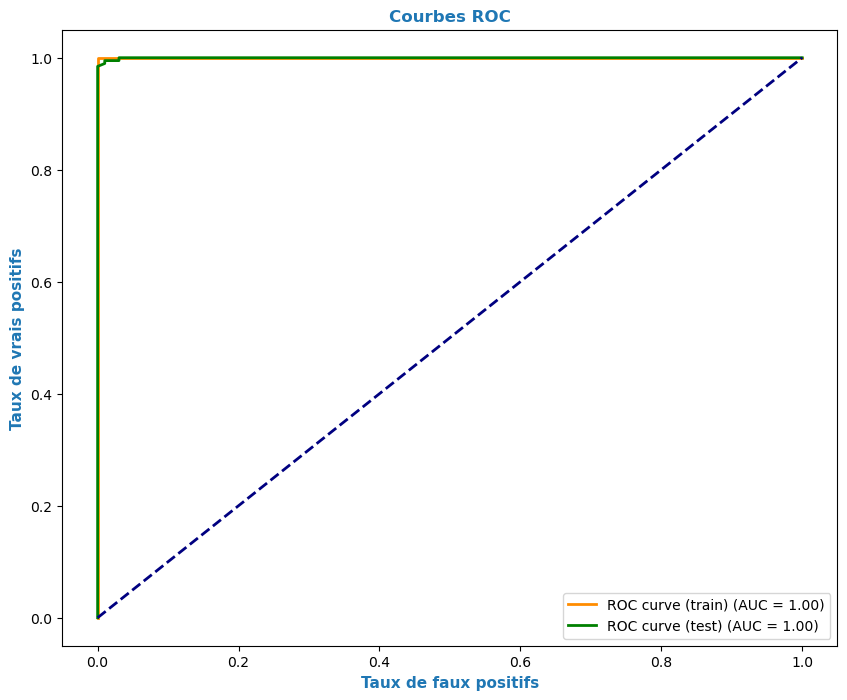

In [175]:
#Initialisation du modèle
#randomForestClassifier = RandomForestClassifier(n_estimators=grid_search.best_params_["n_estimators"], max_depth=grid_search.best_params_["max_depth"], random_state=42)
randomForestClassifier = grid_search.best_estimator_

#Entrainnement du modèle
randomForestClassifier.fit(X_train, y_train)

#Prédictions
y_test_pred = randomForestClassifier.predict(X_test)
y_train_pred = randomForestClassifier.predict(X_train)

#Scores
train_score = randomForestClassifier.score(X_train, y_train)
print('train score',train_score)
test_score = randomForestClassifier.score(X_test, y_test)
print('test score',test_score)

print("precision",precision_score(y_test, y_test_pred))
print("recall",recall_score(y_test, y_test_pred))
print("f1-score",f1_score(y_test, y_test_pred))

#Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred, labels=randomForestClassifier.classes_)
cm_display = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap="Blues")
cm_display.ax_.set_title("Matrice de confusion sur les données de test", fontsize=12, color="#1F77B4", weight="bold")
cm_display.ax_.set_xlabel('Prédiction', fontsize=11, color="#1F77B4", weight="bold");
cm_display.ax_.set_ylabel('Réalité', fontsize=11, color="#1F77B4", weight="bold"); 

plt.show()

#Courbes ROC
y_train_proba = randomForestClassifier.predict_proba(X_train)[:,1]
y_test_proba = randomForestClassifier.predict_proba(X_test)[:,1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color="darkorange", lw=2, label="ROC curve (train) (AUC = %0.2f)" % roc_auc_train)
plt.plot(fpr_test, tpr_test, color="green", lw=2, label="ROC curve (test) (AUC = %0.2f)" % roc_auc_test)
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle='--')
plt.xlabel("Taux de faux positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.ylabel("Taux de vrais positifs", fontsize=11, color="#1F77B4", weight="bold")
plt.title("Courbes ROC", fontsize=12, color="#1F77B4", weight="bold")
plt.legend(loc="lower right")
plt.show()

<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        Le random forest classifier optimisé et non optimisé donne les mêmes résultats
    </p>
</div>

In [176]:
#Sauvegarde des scores dans un dataframe

map_score = {
    "train score": train_score,
    "accuracy":accuracy_score(y_test, y_test_pred),
    "precision":precision_score(y_test, y_test_pred),
    "recall":recall_score(y_test, y_test_pred),
    "f1-score":f1_score(y_test, y_test_pred),
    "ROC":roc_auc_test,
    "Faux positif":3,
    "Faux négatifs":0
}


df_scores_modeles.loc["Random Forest optimisé"] = map_score
df_scores_modeles

,train score,accuracy,precision,recall,f1-score,ROC,Faux positif,Faux négatifs
Régression logistique,0.993162,0.989761,0.984772,1.000000,0.992327,0.999688,3,0
Régression logistique optimisées,0.993162,0.986348,0.984694,0.994845,0.989744,0.999583,3,1
KNN,0.994017,0.982935,0.974874,1.000000,0.987277,0.989196,5,0
Random Forest,1.000000,0.989761,0.984772,1.000000,0.992327,0.999792,3,0
Random Forest optimisé,1.000000,0.989761,0.984772,1.000000,0.992327,0.999766,3,0


<div style="border: 1px solid RGB(31,119,180);" >
<h3 style="margin: auto; padding: 20px; color: RGB(31,119,180); ">4.4 - K-means</h3>
</div>

In [177]:
#Dataframe contenant les caractéristiques des billets
df_caracteristique_billets = df_billets_not_missing_value.drop(labels=['is_genuine', 'is_genuine_int'], axis=1)

#Dataframe contenant le type de billet
df_type_billets = df_billets_not_missing_value['is_genuine_int']

scaler = StandardScaler()
df_caracteristique_billets_scaled = scaler.fit_transform(df_caracteristique_billets)

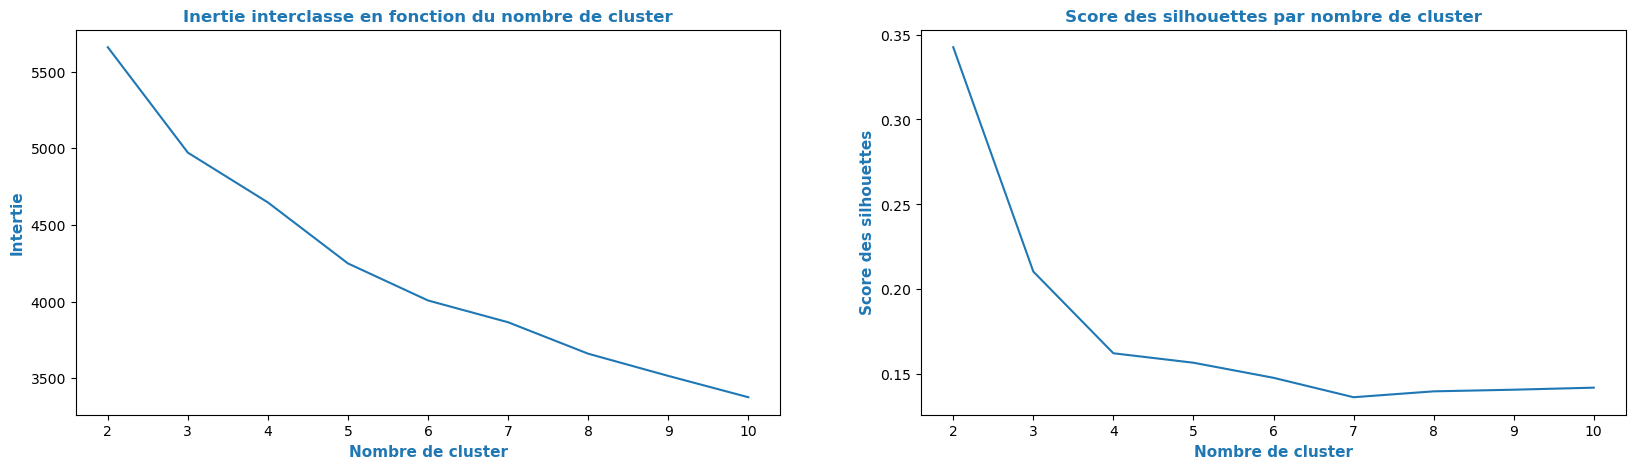

In [178]:
# Liste contenant le nombre de cluster
nb_cluster_list = range(2, 11)

#liste permettant de sauvegarder les silhouettes score
silhouette_score_list = []

#List permettant de sauvegarder l'inertie 
intertia_list = []

for nb_cluster in nb_cluster_list:

    with threadpool_limits(limits=6):
        #Instancitation du modèle k-means pour nb_cluster
        kmeans = KMeans( n_clusters=nb_cluster, random_state = 42)

        #Entrainement du k-means
        kmeans.fit(df_caracteristique_billets_scaled)
    predictions = kmeans.predict(df_caracteristique_billets_scaled)
    silhouette_score_list.append(silhouette_score(df_caracteristique_billets_scaled,predictions))

    #sauvegarde de l'inertie
    intertia_list.append(kmeans.inertia_)

fig, axes = plt.subplots(1,2)
fig.set_size_inches(20, 5)

#Graphique réprésentant l'inertie interclasse en fonction du nombre de cluster
axes[0].plot(nb_cluster_list, intertia_list)
axes[0].set_title("Inertie interclasse en fonction du nombre de cluster", fontsize=12, color="#1F77B4", weight='bold')
axes[0].set_ylabel("Intertie", fontsize=11, color="#1F77B4", weight='bold')
axes[0].set_xlabel("Nombre de cluster", fontsize=11, color="#1F77B4", weight='bold')

#Graphique représentant le score silhouette par nombre de cluster
axes[1].plot(nb_cluster_list, silhouette_score_list)
axes[1].set_title("Score des silhouettes par nombre de cluster", fontsize=12, color="#1F77B4", weight='bold')
axes[1].set_ylabel("Score des silhouettes", fontsize=11, color="#1F77B4", weight='bold')
axes[1].set_xlabel("Nombre de cluster", fontsize=11, color="#1F77B4", weight='bold')

plt.show()

<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        Le score silhouette est plus élevé pour un nombre de cluster de 2
    </p>
</div>

In [179]:
with threadpool_limits(limits=6):
    #Initialisation du modèle K-means
    kmeans = KMeans(n_clusters=2, n_init="auto", random_state = 42)

    #Entrainement du modèle
    kmeans.fit(df_caracteristique_billets_scaled)

#Ajout du label des clusters clusters dans le dataframe
df_billets_not_missing_value = df_billets_not_missing_value.copy()
df_billets_not_missing_value.loc[:,'cluster_labels'] = kmeans.labels_

df_billets_not_missing_value.head(10)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_int,cluster_labels
0,True,171.81,104.86,104.95,4.52,2.89,112.83,1,1
1,True,171.46,103.36,103.66,3.77,2.99,113.09,1,0
2,True,172.69,104.48,103.50,4.40,2.94,113.16,1,0
3,True,171.36,103.91,103.94,3.62,3.01,113.51,1,0
4,True,171.73,104.28,103.46,4.04,3.48,112.54,1,0
5,True,172.17,103.74,104.08,4.42,2.95,112.81,1,0
6,True,172.34,104.18,103.85,4.58,3.26,112.81,1,0
7,True,171.88,103.76,104.08,3.98,2.92,113.08,1,0
8,True,172.47,103.92,103.67,4.00,3.25,112.85,1,0
9,True,172.47,104.07,104.02,4.04,3.25,113.45,1,0


In [180]:
cluster_stat = df_billets_not_missing_value.groupby("cluster_labels").mean()

print("Caractérisitques des clusters")
cluster_stat

Caractérisitques des clusters


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_int
cluster_labels,,,,,,,,
0,0.985656,171.988770,103.947469,103.806814,4.117756,3.053186,113.195973,0.985656
1,0.018480,171.899918,104.199405,104.151273,5.223901,3.353285,111.630185,0.018480


<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        Les billets appartenants au cluster 0 sont majoritairement des vrais billets et ceux appartenants au cluster 1 sont majoritairement des faux billets
    </p>
</div>

In [181]:
geniune_stat = df_billets_not_missing_value.groupby("is_genuine").mean()

print("Caractérisitques de l'authenticité des billets")
geniune_stat

Caractérisitques de l'authenticité des billets


,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_int,cluster_labels
is_genuine,,,,,,,,
False,171.901402,104.188537,104.143272,5.215935,3.351504,111.632114,0.0,0.971545
True,171.988476,103.951679,103.809094,4.116097,3.052544,113.203059,1.0,0.009269


<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        Les faux billets billets appartiennent majoritaitement au cluster 1 et les vrais billets appartennent majoritairement au cluster 0
    </p>
</div>

In [182]:
#Inversement des valeurs de la colonne cluster_labels
df_billets_not_missing_value.loc[:,'cluster_labels_bool'] =df_billets_not_missing_value['cluster_labels'].apply(
    lambda x: True if (x == 0) else False
)

df_billets_not_missing_value.loc[:,'cluster_labels_inv'] =df_billets_not_missing_value['cluster_labels_bool'].apply(
    lambda x: 1 if x is True else 0
)

df_billets_not_missing_value.head(10)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine_int,cluster_labels,cluster_labels_bool,cluster_labels_inv
0,True,171.81,104.86,104.95,4.52,2.89,112.83,1,1,False,0
1,True,171.46,103.36,103.66,3.77,2.99,113.09,1,0,True,1
2,True,172.69,104.48,103.50,4.40,2.94,113.16,1,0,True,1
3,True,171.36,103.91,103.94,3.62,3.01,113.51,1,0,True,1
4,True,171.73,104.28,103.46,4.04,3.48,112.54,1,0,True,1
5,True,172.17,103.74,104.08,4.42,2.95,112.81,1,0,True,1
6,True,172.34,104.18,103.85,4.58,3.26,112.81,1,0,True,1
7,True,171.88,103.76,104.08,3.98,2.92,113.08,1,0,True,1
8,True,172.47,103.92,103.67,4.00,3.25,112.85,1,0,True,1
9,True,172.47,104.07,104.02,4.04,3.25,113.45,1,0,True,1


In [183]:
print("Nombre de billets par cluster")
df_billets_not_missing_value['cluster_labels_inv'].value_counts()

Nombre de billets par cluster


cluster_labels_inv
1    976
0    487
Name: count, dtype: int64

In [184]:
print("Nombre de billets par authenticité")
df_billets_not_missing_value['is_genuine'].value_counts()

Nombre de billets par authenticité


is_genuine
True     971
False    492
Name: count, dtype: int64

<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        Le modèle K-means réparti 20 vrai billets de plus que l'origine
    </p>
</div>

In [185]:
#Dataframe contenant les centroides
df_caracteristique_billets.columns
centers = pd.DataFrame(
    data= scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df_caracteristique_billets.columns
)

print("Dataframe contenant les centroides")
display(centers)

Dataframe contenant les centroides


,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.988946,103.947963,103.807073,4.118158,3.053327,113.195455
1,171.899383,104.198930,104.151461,5.225370,3.353621,111.628004


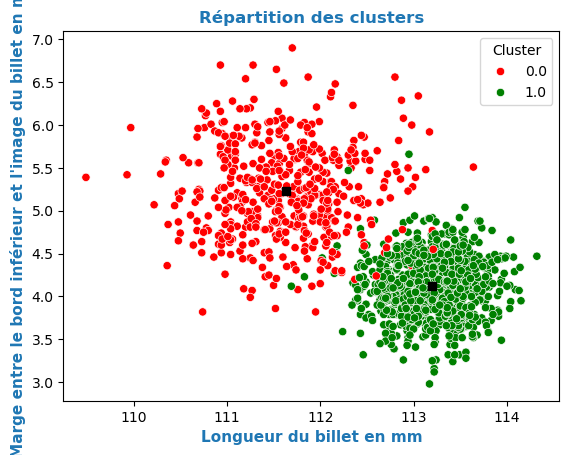

In [186]:
#Réparartion des clusters
sns.scatterplot(data=df_billets_not_missing_value, x = df_billets_not_missing_value.length, y = df_billets.margin_low, hue='cluster_labels_inv', palette=["red","green"])

plt.plot(centers['length'][0], centers['margin_low'][0],  marker="s", c="black" )
plt.plot(centers['length'][1], centers['margin_low'][1],  marker="s", c="black" )

plt.ylabel(map_caracteristiques_billets["margin_low"]+ ' en mm', fontsize=11, color="#1F77B4", weight="bold")
plt.xlabel(map_caracteristiques_billets["length"]+ ' en mm', fontsize=11, color="#1F77B4", weight="bold")
plt.title("Répartition des clusters", fontsize=12, color="#1F77B4", weight="bold")
plt.legend(title="Cluster", loc="best")

plt.show()

In [187]:
#Scores

print("accuracy:", accuracy_score(df_type_billets, df_billets_not_missing_value['cluster_labels_inv']))
print("precision:", precision_score(df_type_billets, df_billets_not_missing_value['cluster_labels_inv']))
print("recall:", recall_score(df_type_billets, df_billets_not_missing_value['cluster_labels_inv']))
print("f1-score:", f1_score(df_type_billets, df_billets_not_missing_value['cluster_labels_inv']))
print("silhouette_score:", silhouette_score(df_caracteristique_billets, kmeans.labels_))

accuracy: 0.9842788790157211
precision: 0.985655737704918
recall: 0.9907312049433573
f1-score: 0.9881869542886492
silhouette_score: 0.5039074172992557


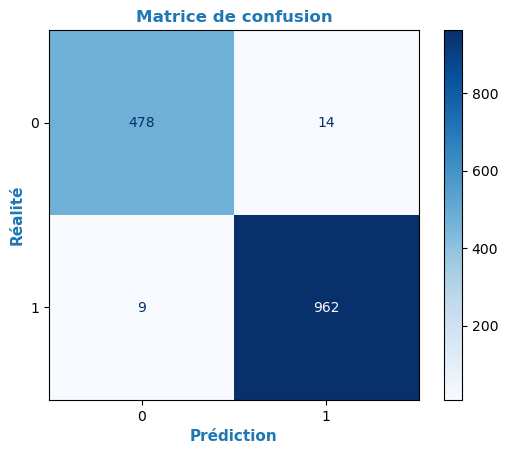

In [188]:
#Matrice de confusion
cm = confusion_matrix(df_type_billets, df_billets_not_missing_value['cluster_labels_inv'])
cm_display = ConfusionMatrixDisplay.from_predictions(df_type_billets, df_billets_not_missing_value['cluster_labels_inv'], cmap='Blues')
cm_display.ax_.set_title("Matrice de confusion", fontsize=12, color="#1F77B4", weight='bold')
cm_display.ax_.set_xlabel('Prédiction', fontsize=11, color="#1F77B4", weight='bold');
cm_display.ax_.set_ylabel('Réalité', fontsize=11, color="#1F77B4", weight='bold'); 
plt.show()

In [189]:
#Sauvegarde des scores dans un dataframe

map_score = {
    "accuracy":accuracy_score(df_type_billets, df_billets_not_missing_value['cluster_labels_inv']),
    "precision":precision_score(df_type_billets, df_billets_not_missing_value['cluster_labels_inv']),
    "recall":recall_score(df_type_billets, df_billets_not_missing_value['cluster_labels_inv']),
    "f1-score":f1_score(df_type_billets, df_billets_not_missing_value['cluster_labels_inv']),
    "Faux positif":14,
    "Faux négatifs":9
}


df_scores_modeles.loc["K-means"] = map_score
df_scores_modeles

,train score,accuracy,precision,recall,f1-score,ROC,Faux positif,Faux négatifs
Régression logistique,0.993162,0.989761,0.984772,1.000000,0.992327,0.999688,3,0
Régression logistique optimisées,0.993162,0.986348,0.984694,0.994845,0.989744,0.999583,3,1
KNN,0.994017,0.982935,0.974874,1.000000,0.987277,0.989196,5,0
Random Forest,1.000000,0.989761,0.984772,1.000000,0.992327,0.999792,3,0
Random Forest optimisé,1.000000,0.989761,0.984772,1.000000,0.992327,0.999766,3,0
K-means,NaN,0.984279,0.985656,0.990731,0.988187,NaN,14,9


<div>
    <p style="margin: auto; padding: 20px 20px 0px 20px; color: RGB(31,119,180);">
        Le random forest donne les meilleurs scores
        <br />
        Le K-means n'est pas une algorithme supervisé
        <br />
    </p>
</div>

<div style="background-color: RGB(31,119,180);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Sélection du meilleur modèle</h2>
</div>

In [190]:
#Initialisation du modèle
param_grid = {
    'n_estimators' : [10,15,20,25,30,40,50, 60, 70, 80, 90, 100, 110, 120],
    'max_depth': [1,2,3,4,5,6,7,8]
}

modele = RandomForestClassifier(random_state=42)

df_billets_not_missing_value = df_billets[df_billets['margin_low'].notna()]

df_billets_not_missing_value_feature = df_billets_not_missing_value[["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]]

grid_search = GridSearchCV(modele, param_grid, cv=5)
grid_search.fit(df_billets_not_missing_value_feature, df_billets_not_missing_value["is_genuine_int"])

# Sauvegarde du modele
joblib.dump(grid_search.best_estimator_, "modele/modele_pipeline_ofcm.joblib")

['modele/modele_pipeline_ofcm.joblib']